# Title

## Imports

In [1]:
import os, sys
print(sys.executable)
print(os.environ.get("LD_PRELOAD"))

from pyseobnr.generate_waveform import GenerateWaveform, SupportedApproximants
print("pyseobnr import works")

/pbs/home/a/amahdi/.conda/envs/lisabeta/bin/python
None


/pbs/home/a/amahdi/.conda/envs/lisabeta/lib/python3.10/site-packages/pyseobnr/generate_waveform.py:6: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


pyseobnr import works


In [2]:
import os
import h5py, json
import itertools
import copy
import warnings
from typing import get_args

import numpy as np
import scipy
from scipy.optimize import minimize
import matplotlib as mpl
import matplotlib.pyplot as plt

from tqdm import tqdm as tqdm

import astropy.cosmology
import astropy.units as u
from astropy.cosmology import Planck15 as cosmo
from pyseobnr.generate_waveform import GenerateWaveform, SupportedApproximants

# Notebook-safe plotting: do not require external LaTeX or Times New Roman.

mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["mathtext.fontset"] = "dejavusans"


In [3]:
import lisabeta
import lisabeta.pyconstants as pyconstants
import lisabeta.tools.pytools as pytools
import lisabeta.tools.pyspline as pyspline
import lisabeta.tools.pyoverlap as pyoverlap
import lisabeta.lisa.pyresponse as pyresponse
import lisabeta.lisa.snrtools as snrtools
import lisabeta.lvk.pyLVKresponse as pyLVKresponse
import lisabeta.lisa.pyLISAnoise as pyLISAnoise
import lisabeta.lisa.lisatools as lisatools
import lisabeta.lisa.lisa as lisa
import lisabeta.lisa.lisa_fisher as lisa_fisher
import lisabeta.utils.plotutils as plotutils

import lal

In [4]:
# gwsurrogate is not needed for pSEOB injections.
# import gwsurrogate


In [5]:
# import sxs
# print(sxs.__version__)

In [6]:
%matplotlib inline

In [7]:
# catalog = sxs.load("catalog")

In [8]:
# dataframe = catalog.table
# dataframe

## Plotting

In [9]:
rc_params = {'backend': 'ps',
            'font.family': 'Times New Roman',
            'font.sans-serif': ['Bitstream Vera Sans'],
            'axes.unicode_minus':False,
            'text.usetex':False,
            'axes.grid':True,
            'grid.linestyle':':',
            'grid.linewidth':1.,
            'hist.bins':50,
            'axes.labelsize':16,
            'axes.titlesize':16,
            'xtick.labelsize':16,
            'ytick.labelsize':16,
            'legend.fontsize':16,
            'savefig.bbox':'tight',
            'savefig.transparent':True,
            'figure.dpi':100}
plt.rcParams.update(rc_params)

In [10]:
plt.rcParams.update({'figure.dpi':100})

In [11]:
# Absolute injection-set directory used by both injection and bias notebooks.
# Keep this exact path so the recovery notebook reads the same files this notebook writes.
Syst_dir = "/pbs/home/a/amahdi/pySEOBNR_deviation/Injection set"
os.makedirs(Syst_dir, exist_ok=True)
print("Syst_dir:", Syst_dir)
print("Syst_dir absolute:", os.path.abspath(Syst_dir))


Syst_dir: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set
Syst_dir absolute: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set


## Parameters and config

In [12]:
# Config id: indices in these lists, in that order
# Injection waveform: pySEOBNR time-domain modes -> FFT -> lisabeta LISA/TDI response.

list_models_inj = ['SEOBNRv5HM']
list_models_temp = ['SEOBNRv5HMROM']
# Keep the same mode content as the original SEOB injection builder.
# This avoids comparing a six-mode original-style injection against a four-mode pSEOB injection.
common_modes = [(2,2), (2,1), (3,3), (4,4), (4,3), (5,5)]
list_modes_inj = [common_modes]
list_modes_temp = [common_modes]

list_M = [1e4, 1e5, 1e6, 1e7, 1e8]
list_q = [2, 4, 8]
list_chi1 = [0., 0.5, 0.95]
list_chi2 = [0., 0.5, 0.95]
list_dfactor = np.power(2., np.arange(-2, 6))
list_inc = [np.pi/18, np.pi/3, np.pi/2-np.pi/18]
list_beta = [np.pi/18, np.pi/6, np.pi/2-np.pi/18]


In [13]:
z_base = 1.
dist_base = cosmo.luminosity_distance(z_base).value
dist_base

np.float64(6791.810623950696)

In [14]:
params_base = {
    'M': 1e6,
    'q': 4,
    'chi1': 0.5,
    'chi2': 0.5,
    'dist': 6791.810623950696,
    'inc': np.pi / 3,
    'phi': 0.7,
    'lambda': 1.0,
    'beta': np.pi / 6,
    'psi': 1.2,
    'Deltat': 0.0,
    'Lframe': True,
}

In [15]:
# In Manuel's code, parameters were set for a FD waveform.
# Since my one is TD, extra control on parameter is needed.
# Base waveform params for pySEOBNR time-domain injections.
# As pySEOBNR is a time-domain generator, so f22_start and deltaT must be controlled.


waveform_params_base = {
    "t0": 0.,

    # Global lower/upper analysis limits.
    # The actual TD start frequency is max(minf, frequency corresponding to T_obs before merger).
    "minf": 1e-5,
    "maxf": 0.2,

    # Time-domain generation controls.
    # Increase T_obs carefully after the pipeline runs.
    "T_obs": 60 * 86400,
    #"T_obs": pyconstants.YRSID_SI,
    #"T_obs": pyconstants.YRSID_SI/2,
    "max_td_samples": 2_000_000,

    # If deltaT is None, it is chosen dynamically from total mass/ringdown scale.
    "deltaT": None,

    # pySEOBNR aligned-spin model.
    "approximant": "SEOBNRv5HM",
    "modes": common_modes,

    # LISA/TDI response options.
    "timetomerger_max": 2.0,
    "DeltalnMf_max": 0.01,
    "TDIrescaled": True,
    "TDI": "TDIAET",
    "LISAnoise": pyLISAnoise.LISAnoiseSciRDv1,

    # Optional pySEOBNR deviation dictionaries; leave absent/empty for GR.
    # "domega_dict": {},
    # "dtau_dict": {},
    # "dA_dict": {},
    # "dw_dict": {},
}
waveform_params_base['LISAnoise']['WDbackground'] = True
waveform_params_base['LISAnoise']['WDduration'] = 4.


# Convention switch:
# - Keep the physical orbital phase `phi` in the LISA response only.
# - Do not also pass `phi` as pySEOBNR `phi_ref`, otherwise the phase convention is double counted.
waveform_params_base["pseob_phi_ref"] = 0.0

# GR-only run: keep all FTI-like deviation parameters explicitly zero and inactive.
# These are written to the parameter files for traceability, but no tgr_params/deviation dictionaries
# are activated unless you explicitly enable them elsewhere.
FTI_ZERO_PARAMS = [
    "fti_dchiMinus2v", "fti_dchi0v", "fti_dchi1v", "fti_dchi2v",
    "fti_dchi3v", "fti_dchi4v", "fti_dchi5lv", "fti_dchi6v",
    "fti_dchi6lv", "fti_dchi7v", "fti_dkappa_S", "fti_dxi0v",
]

print('pySEOBNR supported approximants:', get_args(SupportedApproximants))


pySEOBNR supported approximants: ('SEOBNRv5HM', 'SEOBNRv5PHM', 'SEOBNRv5EHM')


# pSEOB signal generation


## Download datasets (done only once)

In [16]:
# NRSur/gwsurrogate block removed.
# pSEOB signals are generated directly by lisabeta in the cells below.


In [17]:
# NRSur/gwsurrogate block removed.
# pSEOB signals are generated directly by lisabeta in the cells below.


In [18]:
# NRSur/gwsurrogate block removed.
# pSEOB signals are generated directly by lisabeta in the cells below.


## Loading datasets

In [19]:
# NRSur/gwsurrogate block removed.
# pSEOB signals are generated directly by lisabeta in the cells below.


In [20]:
# NRSur/gwsurrogate block removed.
# pSEOB signals are generated directly by lisabeta in the cells below.


# Automated generation of pSEOB signals


## Definitions

In [21]:
# Same as the original code
# Trying to downsample according to spline interpolation error criterion, translated to time domain -- see BuildFrequencyGrid in tools.c

def Deltat_insp(nu, t, acc=1e-4, tc=0.):
    Lambda = 8./3 * np.pi**(5./12) * (acc * nu)**(1./4)
    return 8*Lambda/3 * 5./(256*nu) * (256*nu/5 * (tc-t))**(27/32.)

def downsamplemask_arr_byfunc(x, func_dx):
    mask_ds = np.zeros_like(x, dtype=bool)
    i = 0
    while (i < len(x)-1):
        mask_ds[i] = True
        dx = x[i+1] - x[i]
        dx_func = func_dx(x[i])
        i += int(dx_func/dx)
    mask_ds[len(x)-1] = True
    return mask_ds

### Consistency fixes for injection/recovery comparisons

This notebook keeps the pSEOB injection in GR, writes into the same absolute directory used by the bias notebook, and uses one phase convention consistently:

1. The output/input directory is `/pbs/home/a/amahdi/pySEOBNR_deviation/Injection set`.
2. The physical orbital phase `phi` is applied in the LISA response only; pySEOBNR receives `phi_ref = 0`.
3. The frequency-domain time shift uses `phase += 2π f Deltat` together with `tf += Deltat`.
4. The generated TDI file now stores `TDIA`, `TDIE`, and `TDIT`, so beta/Fisher/mismatch can use the same A/E/T channel set.
5. FTI-like parameters are explicitly written as zero for traceability, but no FTI/tgr corrections are activated.


In [22]:
# ============================================================
# pySEOBNR TD -> FD modes, written close to the original SEOB cell
# ============================================================

def mode_key_variants(lm):
    l, m = lm
    return [lm, (l, m), f"{l},{m}", f"{l}{m}", f"h{l}{m}"]


def get_mode_from_dict(hlm, lm):
    for key in mode_key_variants(lm):
        if key in hlm:
            return hlm[key]
    raise KeyError(f"Mode {lm} not found. Available keys: {list(hlm.keys())[:20]}")


def choose_f_start_from_Tobs(m1, m2, waveform_params):
    f_min_user = waveform_params.get("minf", 1e-5)
    T_obs = waveform_params.get("T_obs", 3 * 86400)
    f_from_T = pytools.funcNewtonianfoft(m1, m2, T_obs)
    return max(f_min_user, f_from_T), T_obs, f_from_T


def choose_deltaT(M, waveform_params):
    maxf = float(waveform_params.get("maxf", 0.2))
    user_deltaT = waveform_params.get("deltaT", None)

    M_seconds = M * pyconstants.MTSUN_SI
    f_rd_est = 0.08 / M_seconds

    delta_from_maxf = 1.0 / (4.0 * maxf)
    delta_from_ringdown = 1.0 / (8.0 * f_rd_est)
    auto_deltaT = min(delta_from_maxf, delta_from_ringdown)

    if user_deltaT is None:
        return auto_deltaT, f_rd_est

    return min(float(user_deltaT), auto_deltaT), f_rd_est


def generate_pseob_td(params, modes=None, waveform_params=None, verbose=True):
    """
    Generate pySEOBNR time-domain h_lm modes.

    This replaces the NRSur time-domain generation part of the original notebook.
    Everything after this is kept as close as possible to the original FFT logic.
    """

    if waveform_params is None:
        waveform_params = waveform_params_base

    if modes is None:
        modes = waveform_params.get(
            "modes",
            [(2,2), (2,1), (3,3), (4,4), (4,3), (5,5)]
        )

    M = float(params["M"])
    q = float(params["q"])

    m1 = M * q / (1.0 + q)
    m2 = M / (1.0 + q)

    chi1 = float(params.get("chi1", 0.0))
    chi2 = float(params.get("chi2", 0.0))

    distance = float(params.get("dist", 1.0))
    inclination = float(params.get("inc", 0.0))
    phi_ref = float(waveform_params.get("pseob_phi_ref", 0.0))

    f_min, T_obs, f_from_T = choose_f_start_from_Tobs(m1, m2, waveform_params)
    f_max = float(waveform_params.get("maxf", 0.2))

    deltaT, f_rd_est = choose_deltaT(M, waveform_params)

    approx = waveform_params.get("approximant", "SEOBNRv5HM")

    params_pseob = {
        "mass1": m1,
        "mass2": m2,
        "spin1x": 0.0,
        "spin1y": 0.0,
        "spin1z": chi1,
        "spin2x": 0.0,
        "spin2y": 0.0,
        "spin2z": chi2,
        "distance": distance,
        "inclination": inclination,
        "phi_ref": phi_ref,
        "f22_start": f_min,
        "f_ref": f_min,
        "f_max": f_max,
        "deltaT": deltaT,
        "approximant": approx,
        "mode_array": modes,
    }

    for key in ["domega_dict", "dtau_dict", "dA_dict", "dw_dict", "lmax_nyquist"]:
        if key in waveform_params:
            params_pseob[key] = waveform_params[key]

    if verbose:
        print(
            f"pySEOBNR TD: M={M:.3e}, q={q:.3f}, "
            f"chi1={chi1:.3f}, chi2={chi2:.3f}, "
            f"f22_start={f_min:.3e} Hz, f_from_T={f_from_T:.3e} Hz, "
            f"f_RD_est={f_rd_est:.3e} Hz, f_max={f_max:.3e} Hz, "
            f"deltaT={deltaT:.3e} s, phi_ref={phi_ref:.6g}"
        )

    times, hlm_raw = GenerateWaveform(params_pseob).generate_td_modes()
    times = np.asarray(times)

    hlm_out = {}

    for lm in modes:
        try:
            hlm_out[lm] = np.asarray(get_mode_from_dict(hlm_raw, lm), dtype=complex)
        except KeyError:
            warnings.warn(f"Requested mode {lm} was not returned by pySEOBNR. Skipping.")

    if not hlm_out:
        raise RuntimeError(f"No requested modes returned. Available keys: {list(hlm_raw.keys())[:20]}")

    return times, hlm_out


def generate_pseob_fft(
    params,
    modes=None,
    waveform_params=None,
    verbose=True,
):
    """
    Generate pSEOB frequency-domain modes.

    This is intentionally written close to the original generate_nrsur_spa_fft cell.

    Original notebook logic kept here:
        1. generate time-domain modes
        2. apply Planck taper
        3. zeropad
        4. FFT
        5. interpolate amplitude and phase to a clean geomspace grid
        6. compute tf = 1/(2*pi) d phase/df

    Difference from original:
        Instead of NRSur SPA+FFT hybridization, this uses the pSEOB time-domain
        modes and their FFT only.
    """

    if waveform_params is None:
        waveform_params = waveform_params_base

    if modes is None:
        modes = waveform_params.get(
            "modes",
            [(2,2), (2,1), (3,3), (4,4), (4,3), (5,5)]
        )

    Deltat_w_end = 40.0
    Deltat_w_beg = 10000.0

    minf = float(waveform_params.get("minf", 1e-5))
    maxf = float(waveform_params.get("maxf", 0.2))
    n_freq = int(waveform_params.get("n_freq", 10000))

    # ------------------------------------------------------------
    # Time-domain pSEOB waveform
    # ------------------------------------------------------------

    t, h = generate_pseob_td(
        params,
        modes=modes,
        waveform_params=waveform_params,
        verbose=verbose,
    )

    # FFT requires a uniform time grid.
    dt_arr = np.diff(t)

    if len(dt_arr) == 0:
        raise ValueError("The time-domain waveform has fewer than two samples.")

    if not np.allclose(dt_arr, dt_arr[0], rtol=1e-5, atol=0):
        raise ValueError(
            "pySEOBNR returned a non-uniform time grid. "
            "This original-style FFT cell assumes uniform sampling."
        )

    # ------------------------------------------------------------
    # Compute FFT, following the original notebook structure
    # ------------------------------------------------------------

    w = pytools.window_planck_vec(t, t[0], t[-1], Deltat_w_beg, Deltat_w_end)

    hlm_fft = {}

    for lm in modes:
        if lm not in h:
            warnings.warn(f"Mode {lm} missing from pSEOB TD output. Skipping.")
            continue

        hlm_ts = np.array([
            t,
            w * np.real(h[lm]),
            w * np.imag(h[lm])
        ]).T

        hlm_ts = pytools.zeropad(hlm_ts, extend=1)

        # Same FFT call as the original notebook.
        hlm_fs = pytools.fft_positivef(hlm_ts)

        freq = hlm_fs[:, 0]
        hf = hlm_fs[:, 1] + 1j * hlm_fs[:, 2]

        amp = np.abs(hf)
        phase = np.unwrap(np.angle(hf))

        hlm_fft[lm] = {}
        hlm_fft[lm]["freq"] = freq
        hlm_fft[lm]["amp"] = amp
        hlm_fft[lm]["phase"] = phase

    if not hlm_fft:
        raise RuntimeError("No modes were converted to frequency domain.")

    # ------------------------------------------------------------
    # Interpolate onto a clean geometric frequency grid
    # ------------------------------------------------------------

    f_low_available = max([hlm_fft[lm]["freq"][0] for lm in hlm_fft])
    f_high_available = min([hlm_fft[lm]["freq"][-1] for lm in hlm_fft])

    if minf < f_low_available:
        raise ValueError(
            f"minf={minf:.6e} is not covered by all pSEOB FFT modes. "
            f"The common lower limit is {f_low_available:.6e}."
        )

    if maxf > f_high_available:
        raise ValueError(
            f"maxf={maxf:.6e} is not covered by all pSEOB FFT modes. "
            f"The common upper limit is {f_high_available:.6e}."
        )


    M = float(params["M"])
    q = float(params["q"])
    
    m1 = M * q / (1.0 + q)
    m2 = M / (1.0 + q)
    
    f_min, T_obs, f_from_T = choose_f_start_from_Tobs(
    m1, m2, waveform_params
    )
    
    freq = np.geomspace(minf, maxf, n_freq)
    
    hlm_fd = {}

    for lm in modes:
        if lm not in hlm_fft:
            continue

        spline_amp_fft = pytools.spline(
            hlm_fft[lm]["freq"],
            hlm_fft[lm]["amp"]
        )

        spline_phase_fft = pytools.spline(
            hlm_fft[lm]["freq"],
            hlm_fft[lm]["phase"]
        )

        mask_fft = (
            (hlm_fft[lm]["freq"][0] <= freq)
            & (freq <= hlm_fft[lm]["freq"][-1])
        )

        amp = np.zeros_like(freq)
        phase = np.zeros_like(freq)

        amp[mask_fft] = spline_amp_fft(freq[mask_fft])
        phase[mask_fft] = spline_phase_fft(freq[mask_fft])

        hlm_fd[lm] = {}
        hlm_fd[lm]["freq"] = freq.copy()
        hlm_fd[lm]["amp"] = amp.copy()
        hlm_fd[lm]["phase"] = phase.copy()

        hlm_fd[lm]["tf"] = (
            1.0 / (2.0 * np.pi)
            * pytools.spline(
                hlm_fd[lm]["freq"],
                hlm_fd[lm]["phase"]
            )(hlm_fd[lm]["freq"], 1)
        )

        hlm_fd[lm]["h"] = (
            hlm_fd[lm]["amp"]
            * np.exp(1j * hlm_fd[lm]["phase"])
        )

    if verbose:
        print("pSEOB FD construction:")
        print("  modes kept =", list(hlm_fd.keys()))
        print("  freq range =", freq[0], freq[-1])
        print("  n_freq     =", len(freq))

    return hlm_fd

In [23]:
# ============================================================
# Build lisabeta LISA/TDI response from external pSEOB FD modes
# ============================================================

def build_wftdi_from_hlm_fd(
    params,
    hlm_fd,
    modes,
    t0=0.0,
    TDI="TDIAET",
    TDIrescaled=True,
):
    """
    Build the wftdi dictionary expected by lisabeta from external h_lm(f) modes.

    This is the pSEOB analogue of the original notebook block:

        wftdi[lm]['freq']  = ...
        wftdi[lm]['amp']   = ...
        wftdi[lm]['phase'] = ...
        wftdi[lm]['tf']    = ...
        pyresponse.LISAFDresponseTDI3Chan(...)

    It does not introduce a new waveform operation. It only attaches the
    lisabeta LISA/TDI response to the already-built pSEOB FD modes.
    """

    params_local = copy.deepcopy(params)

    if params_local.get("Lframe", False):
        params_local = lisatools.convert_Lframe_to_SSBframe(params_local, t0=t0)
        params_local["Lframe"] = False

    Deltat = params_local["Deltat"]
    inc = params_local["inc"]
    phi = params_local["phi"]
    lambd = params_local["lambda"]
    beta = params_local["beta"]
    psi = params_local["psi"]

    wftdi = {"modes": []}

    for lm in modes:
        if lm not in hlm_fd:
            warnings.warn(f"Mode {lm} missing from hlm_fd. Skipping.")
            continue

        freq = np.asarray(hlm_fd[lm]["freq"])
        amp = np.asarray(hlm_fd[lm]["amp"])
        phase = np.asarray(hlm_fd[lm]["phase"])
        tf = np.asarray(hlm_fd[lm]["tf"])

        good = (
            np.isfinite(freq)
            & np.isfinite(amp)
            & np.isfinite(phase)
            & np.isfinite(tf)
            & (freq > 0)
        )

        freq = freq[good]
        amp = amp[good]
        phase = phase[good]
        tf = tf[good]

        if len(freq) < 10:
            warnings.warn(f"Mode {lm} has too few valid FD samples. Skipping.")
            continue

        wftdi["modes"].append(lm)

        # Use the same dimensional convention as tf = (1/2π) d phase / df.
        # A time shift Deltat is represented by phase += 2π f Deltat,
        # which implies tf += Deltat.
        wftdi[lm] = {}
        wftdi[lm]["freq"] = freq
        wftdi[lm]["amp"] = amp
        wftdi[lm]["phase"] = phase + (2.0 * np.pi) * freq * Deltat
        wftdi[lm]["tf"] = tf + Deltat

        tdiClass = pyresponse.LISAFDresponseTDI3Chan(
            wftdi[lm]["freq"],
            wftdi[lm]["tf"],
            t0,
            lm[0],
            lm[1],
            inc,
            phi,
            lambd,
            beta,
            psi,
            TDI=TDI,
            TDIrescaled=TDIrescaled,
        )

        (
            wftdi[lm]["phaseRdelay"],
            wftdi[lm]["transferL1"],
            wftdi[lm]["transferL2"],
            wftdi[lm]["transferL3"],
        ) = tdiClass.get_response()

    if not wftdi["modes"]:
        raise RuntimeError("No modes were available for TDI response construction.")

    return params_local, wftdi


def make_frequency_grid_from_hlm_fd(
    params,
    hlm_fd,
    waveform_params=None,
    Deltalnf=5e-4,
    refine=1,
):
    """
    Build the final response frequency grid.

    This follows the same spirit as the original notebook:

        fLow  = max(waveform lower limit, minf)
        fHigh = min(waveform upper limit, maxf)
        fLow  = max(fLow, funcNewtonianfoft(m1, m2, T))
        freq_nyq_log = composite_nyquist_log_freq_grid(...)

    For pSEOB, the available frequency support is taken from the generated
    hlm_fd modes instead of NRSur's Mflow_sur/Mfhigh_sur arrays.
    """

    if waveform_params is None:
        waveform_params = waveform_params_base

    M = float(params["M"])
    q = float(params["q"])

    m1 = M * q / (1.0 + q)
    m2 = M / (1.0 + q)

    modes = waveform_params.get("modes", list(hlm_fd.keys()))

    f_lows = []
    f_highs = []

    for lm in modes:
        if lm not in hlm_fd:
            continue

        f = np.asarray(hlm_fd[lm]["freq"])
        f = f[np.isfinite(f) & (f > 0)]

        if len(f) < 2:
            continue

        f_lows.append(f[0])
        f_highs.append(f[-1])

    if len(f_lows) == 0:
        raise RuntimeError("Cannot build frequency grid: no valid mode frequency arrays.")

    '''fLow = np.fmax(max(f_lows), waveform_params.get("minf", 1e-5))
    fHigh = np.fmin(min(f_highs), waveform_params.get("maxf", 0.2))

    # Important addition after ChatGPT's suggestion
    fLow = np.fmax(fLow, f_min_phys)

    T_est = pytools.funcNewtoniantoff(m1, m2, fLow)
    T = np.fmin(pyconstants.YRSID_SI, np.fmax(30.0 * 86400.0, T_est))'''

    fLow = np.fmax(max(f_lows), waveform_params.get("minf", 1e-5))
    fHigh = np.fmin(min(f_highs), waveform_params.get("maxf", 0.2))
    
    # Recompute the actual physical starting frequency inside this function.
    # The f_min_phys defined in generate_pseob_fft is local to that function
    # and cannot be used here.
    f_min_phys, T_obs_start, f_from_T = choose_f_start_from_Tobs(
        m1, m2, waveform_params
    )
    
    fLow = waveform_params["minf"]
    
    T_est = pytools.funcNewtoniantoff(m1, m2, fLow)
    T = np.fmin(pyconstants.YRSID_SI, np.fmax(30.0 * 86400.0, T_est))

    fLow = np.fmax(fLow, pytools.funcNewtonianfoft(m1, m2, T))

    if not (fLow < fHigh):
        raise ValueError(f"Bad response frequency range: fLow={fLow}, fHigh={fHigh}")

    freq_nyq_log = pytools.composite_nyquist_log_freq_grid(
        fLow,
        fHigh,
        m1,
        m2,
        Deltalnf=Deltalnf,
        refine=refine,
    )

    return freq_nyq_log

## Corners of the parameter space

In [24]:
n_corners = 4

q_corners = np.array([1.1, 1.1, 8., 8.])
chi1_corners = np.array([0.8, -0.8, 0.8, -0.8])
chi2_corners = np.array([0.8, -0.8, 0.8, -0.8])

In [25]:
from lisabeta.lisa import lisa

print(lisa.list_approximants_smbh)

['IMRPhenomD', 'IMRPhenomHM', 'IMRPhenomX', 'IMRPhenomXHM', 'EOBNRv2HMROM', 'SEOBNRv4HMROM', 'SEOBNRv5HMROM', 'TaylorF2Ecc']


In [26]:
modes = waveform_params_base["modes"]

hlm_fd_pseob_corner = {}

for i in tqdm(range(n_corners)):
    params = copy.deepcopy(params_base)
    params["q"] = q_corners[i]
    params["chi1"] = chi1_corners[i]
    params["chi2"] = chi2_corners[i]

    hlm_fd_pseob_corner[i] = generate_pseob_fft(
        params,
        modes=modes,
        waveform_params=waveform_params_base,
        verbose=True,
    )

  0%|          | 0/4 [00:00<?, ?it/s]

pySEOBNR TD: M=1.000e+06, q=1.100, chi1=0.800, chi2=0.800, f22_start=1.372e-04 Hz, f_from_T=1.372e-04 Hz, f_RD_est=1.624e-02 Hz, f_max=2.000e-01 Hz, deltaT=1.250e+00 s, phi_ref=0


 25%|██▌       | 1/4 [00:58<02:55, 58.38s/it]

pSEOB FD construction:
  modes kept = [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]
  freq range = 1e-05 0.2
  n_freq     = 10000
pySEOBNR TD: M=1.000e+06, q=1.100, chi1=-0.800, chi2=-0.800, f22_start=1.372e-04 Hz, f_from_T=1.372e-04 Hz, f_RD_est=1.624e-02 Hz, f_max=2.000e-01 Hz, deltaT=1.250e+00 s, phi_ref=0


 50%|█████     | 2/4 [01:21<01:15, 37.55s/it]

pSEOB FD construction:
  modes kept = [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]
  freq range = 1e-05 0.2
  n_freq     = 10000
pySEOBNR TD: M=1.000e+06, q=8.000, chi1=0.800, chi2=0.800, f22_start=1.941e-04 Hz, f_from_T=1.941e-04 Hz, f_RD_est=1.624e-02 Hz, f_max=2.000e-01 Hz, deltaT=1.250e+00 s, phi_ref=0


 75%|███████▌  | 3/4 [02:04<00:39, 39.93s/it]

pSEOB FD construction:
  modes kept = [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]
  freq range = 1e-05 0.2
  n_freq     = 10000
pySEOBNR TD: M=1.000e+06, q=8.000, chi1=-0.800, chi2=-0.800, f22_start=1.941e-04 Hz, f_from_T=1.941e-04 Hz, f_RD_est=1.624e-02 Hz, f_max=2.000e-01 Hz, deltaT=1.250e+00 s, phi_ref=0


100%|██████████| 4/4 [02:29<00:00, 37.42s/it]

pSEOB FD construction:
  modes kept = [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]
  freq range = 1e-05 0.2
  n_freq     = 10000


In [27]:
hlm_fd_pseob_corner[0][(2,2)].keys()


dict_keys(['freq', 'amp', 'phase', 'tf', 'h'])

In [28]:
modes

[(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]

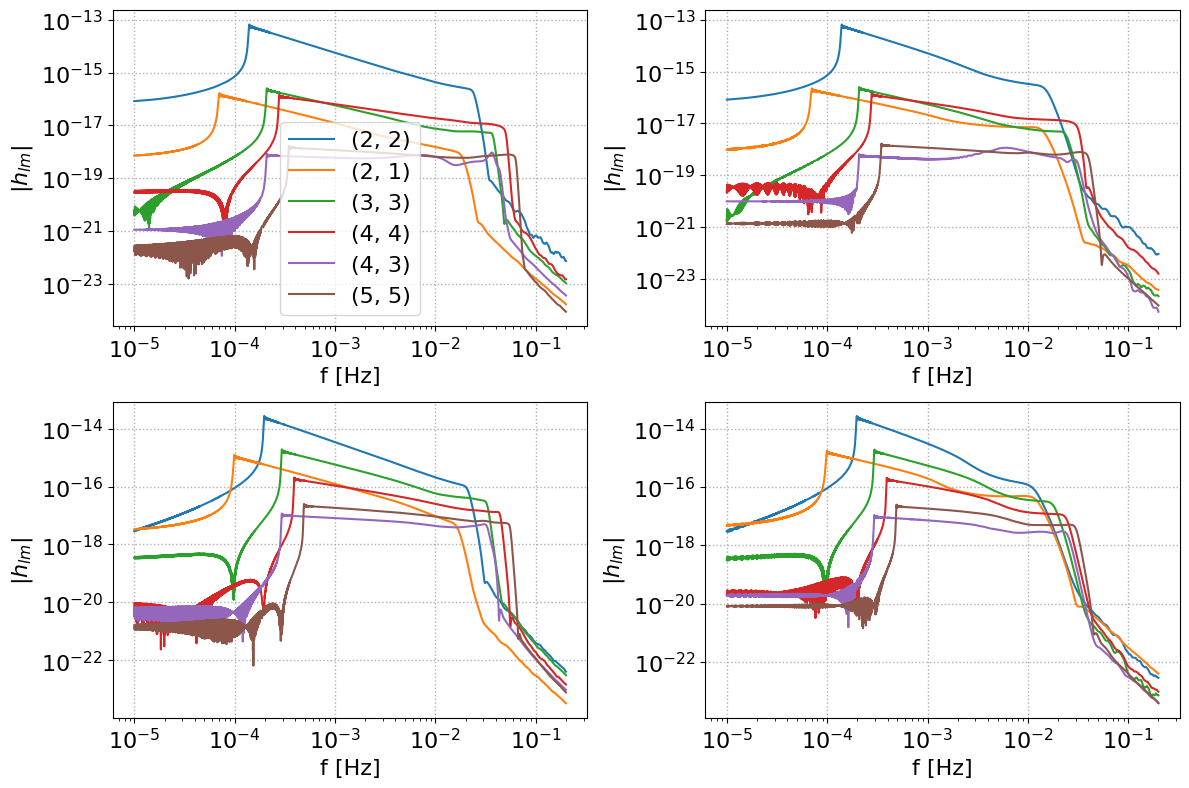

In [29]:
# q, chi1, chi2 [0,3]
fig, axs = plt.subplots(2, 2, figsize=[12, 8])

for i_corner in range(4):
    row, col = divmod(i_corner, 2)
    ax = axs[row][col]
    for lm in modes:
        ax.loglog(hlm_fd_pseob_corner[i_corner][lm]['freq'],
                  hlm_fd_pseob_corner[i_corner][lm]['amp'],
                  label=str(lm) if i_corner == 0 else None)
    if i_corner == 0:
        ax.legend(loc='best')
    ax.set_xlabel('f [Hz]')
    ax.set_ylabel(r'$|h_{lm}|$')

plt.tight_layout()


## Catalog of geom params (q,chi1,chi2)

In [30]:
np.random.seed(1)

N = 1

# Fixed debugging point. For a random injection set, replace by ranges such as:
# q = np.random.uniform(1.1, 8.0, size=N)
# chi1 = np.random.uniform(-0.8, 0.8, size=N)
# chi2 = np.random.uniform(-0.8, 0.8, size=N)
q = 4 * np.ones(N)
chi1 = 0.5 * np.ones(N)
chi2 = 0.5 * np.ones(N)

geom_file = os.path.join(Syst_dir, 'geomparams_injection_set.h5')
with h5py.File(geom_file, 'w') as f:
    f.create_dataset('q', data=q)
    f.create_dataset('chi1', data=chi1)
    f.create_dataset('chi2', data=chi2)

print('Saved:', geom_file)


Saved: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/geomparams_injection_set.h5


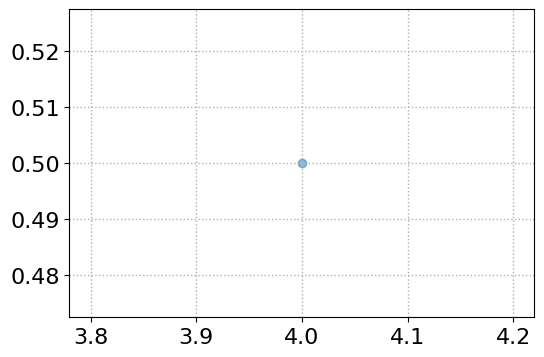

In [31]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.scatter(q, chi1, alpha=0.5)

In [32]:
# No separate NRSur h_lm hybrid files are needed anymore.
# pSEOB is generated directly inside the injection loop below.
success = np.ones(N, dtype=bool)


In [33]:
q, chi1, chi2

(array([4.]), array([0.5]), array([0.5]))

In [34]:
np.arange(N)[~success]

array([], dtype=int64)

In [35]:
# i_failures = [38,133]

In [36]:
[(q[i], chi1[i], chi2[i]) for i in np.arange(N)[~success]]

[]

## Catalogs with all orientation params randomized for M=1e5,1e6,1e7

In [37]:
injection_set = {}
geom_file = os.path.join(Syst_dir, 'geomparams_injection_set.h5')

with h5py.File(geom_file, 'r') as hf:
    injection_set['q'] = hf['q'][:]
    injection_set['chi1'] = hf['chi1'][:]
    injection_set['chi2'] = hf['chi2'][:]

print('Loaded:', geom_file)


Loaded: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/geomparams_injection_set.h5


In [38]:
listM = [1e5, 1e6, 1e7]
listM_str = ['M1e5', 'M1e6', 'M1e7']

Lframe = True

np.random.seed(1)

dist = dist_base * np.ones(N, dtype=float)
Deltat = np.zeros(N, dtype=float)
inc = np.random.uniform(low=np.pi/3, high=np.pi/3, size=N)
phi = np.random.uniform(low=0.7, high=0.7, size=N)
lambda_ = np.random.uniform(low=1, high=1, size=N)
beta = np.random.uniform(low=np.pi/6, high=np.pi/6, size=N)
psi = np.random.uniform(low=1.2, high=1.2, size=N)

for iM in range(3):
    M = listM[iM]
    params_file = os.path.join(Syst_dir, 'params_injection_set_' + listM_str[iM] + '.h5')
    with h5py.File(params_file, 'w') as hf:
        hf.create_dataset('M', data=M * np.ones(N, dtype=float))
        hf.create_dataset('q', data=injection_set['q'])
        hf.create_dataset('chi1', data=injection_set['chi1'])
        hf.create_dataset('chi2', data=injection_set['chi2'])
        hf.create_dataset('Deltat', data=Deltat)
        hf.create_dataset('dist', data=dist)
        hf.create_dataset('inc', data=inc)
        hf.create_dataset('phi', data=phi)
        hf.create_dataset('lambda', data=lambda_)
        hf.create_dataset('beta', data=beta)
        hf.create_dataset('psi', data=psi)
        hf.create_dataset('Lframe', data=np.array([int(Lframe)]))
        for p in FTI_ZERO_PARAMS:
            hf.create_dataset(p, data=np.zeros(N, dtype=float))
    print('Saved:', params_file)


Saved: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/params_injection_set_M1e5.h5
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/params_injection_set_M1e6.h5
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/params_injection_set_M1e7.h5


## Generate LISA signals for injection catalogs

In [39]:
# pSEOB does not require loading precomputed NRSur h_lm hybrid files.
data_dir = Syst_dir
listM = [1e5, 1e6, 1e7]
listM_str = ['M1e5', 'M1e6', 'M1e7']
N = 1
modes = [(2,2), (2,1), (3,3), (4,4), (4,3), (5,5)]


In [40]:
# Optional plotting/reference frequencies can still be defined here if needed.
# They are no longer used to damp NRSur FFT artefacts.
fdamp = {
    (2,2): 0.14,
    (2,1): 0.11,
    (3,3): 0.18,
    (3,2): 0.14,
    (4,4): 0.22,
    #(4,3): 0.2,
    #(5,5): 0.3,
}


In [41]:
# No mass-rescaling of precomputed geometric NRSur files is needed.
# pSEOB receives the physical mass M directly through params['M'].


In [42]:
# Generate pySEOBNR injections and apply the lisabeta LISA/TDI response.
# This creates files readable by inference.load_data_TDIAET: freq, TDIA, TDIE, TDIT.

inj_dir = Syst_dir

modes_out = waveform_params_base["modes"]
modes = waveform_params_base["modes"]

t0 = waveform_params_base['t0']
TDI = waveform_params_base.get('TDI', 'TDIAET')
TDIrescaled = waveform_params_base.get('TDIrescaled', True)

list_params = ['M', 'q', 'chi1', 'chi2', 'Deltat', 'dist', 'inc', 'phi', 'lambda', 'beta', 'psi']

for iM in range(3):
    params_file = os.path.join(Syst_dir, 'params_injection_set_' + listM_str[iM] + '.h5')
    injection_set_params = {}

    print('Reading:', params_file)
    with h5py.File(params_file, 'r') as hf:
        for p in list_params:
            injection_set_params[p] = hf[p][:]
        injection_set_params['Lframe'] = bool(hf['Lframe'][:][0])

    out_dir = os.path.join(inj_dir, listM_str[iM])
    os.makedirs(out_dir, exist_ok=True)
    print('Writing:', out_dir)

    for i in tqdm(range(N)):
        params = {p: injection_set_params[p][i] for p in list_params}
        params['Lframe'] = injection_set_params['Lframe']

        # 1. Generate pySEOBNR time-domain modes and FFT them.
        hlm_fd = generate_pseob_fft(
            params,
            modes=modes,
            waveform_params=waveform_params_base,
            verbose=True,
        )

        # 2. Save raw frequency-domain h_lm modes.
        hlm_out_file = os.path.join(out_dir, 'hlm_fd_pseob_' + listM_str[iM] + '_id_' + str(i) + '.h5')
        with h5py.File(hlm_out_file, 'w') as hf:
            for lm, data in hlm_fd.items():
                g = hf.create_group('h' + str(lm[0]) + str(lm[1]))
                for k in ['freq', 'h', 'amp', 'phase', 'tf']:
                    g.create_dataset(k, data=data[k])

        # 3. Build response-ready wftdi dictionary and attach LISA/TDI response.
        params_ssb, wftdi = build_wftdi_from_hlm_fd(
            params,
            hlm_fd,
            modes=modes,
            t0=t0,
            TDI=TDI,
            TDIrescaled=TDIrescaled,
        )

        # 4. Build final response frequency grid and evaluate complex TDI series.
        freq_nyq_log = make_frequency_grid_from_hlm_fd(
            params_ssb,
            hlm_fd,
            waveform_params=waveform_params_base,
            Deltalnf=5e-4,
            refine=1,
        )

        tdi = lisa.GetCAmpPhaseTDI(wftdi)
        tdi_fs = lisa.EvaluateTDIFreqseries(tdi, freq_nyq_log)

        data_out = {
            'freq': freq_nyq_log,
            'TDIA': np.zeros_like(freq_nyq_log, dtype=complex),
            'TDIE': np.zeros_like(freq_nyq_log, dtype=complex),
            'TDIT': np.zeros_like(freq_nyq_log, dtype=complex),
        }

        for lm in modes_out:
            if lm in tdi_fs:
                data_out['TDIA'] += tdi_fs[lm]['chan1']
                data_out['TDIE'] += tdi_fs[lm]['chan2']
                data_out['TDIT'] += tdi_fs[lm]['chan3']

        data_out_file = os.path.join(out_dir, 'data_pseob_' + listM_str[iM] + '_id_' + str(i) + '.h5')
        with h5py.File(data_out_file, 'w') as hf:
            hf.create_dataset('freq', data=data_out['freq'])
            hf.create_dataset('TDIA', data=data_out['TDIA'])
            hf.create_dataset('TDIE', data=data_out['TDIE'])
            hf.create_dataset('TDIT', data=data_out['TDIT'])

        # 5. Save mode-by-mode TDI contributions.
        datalm_out_file = os.path.join(out_dir, 'datalm_pseob_' + listM_str[iM] + '_id_' + str(i) + '.h5')
        with h5py.File(datalm_out_file, 'w') as hf:
            for lm in modes:
                if lm in tdi_fs:
                    g = hf.create_group('h' + str(lm[0]) + str(lm[1]))
                    g.create_dataset('freq', data=freq_nyq_log)
                    g.create_dataset('TDIA', data=tdi_fs[lm]['chan1'])
                    g.create_dataset('TDIE', data=tdi_fs[lm]['chan2'])
                    g.create_dataset('TDIT', data=tdi_fs[lm]['chan3'])

        print('Saved:', hlm_out_file)
        print('Saved:', data_out_file)
        print('Saved:', datalm_out_file)



Reading: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/params_injection_set_M1e5.h5
Writing: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/M1e5


  0%|          | 0/1 [00:00<?, ?it/s]

pySEOBNR TD: M=1.000e+05, q=4.000, chi1=0.500, chi2=0.500, f22_start=6.832e-04 Hz, f_from_T=6.832e-04 Hz, f_RD_est=1.624e-01 Hz, f_max=2.000e-01 Hz, deltaT=7.696e-01 s, phi_ref=0
pSEOB FD construction:
  modes kept = [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]
  freq range = 1e-05 0.2
  n_freq     = 10000


100%|██████████| 1/1 [00:49<00:00, 49.61s/it]


Saved: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/M1e5/hlm_fd_pseob_M1e5_id_0.h5
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/M1e5/data_pseob_M1e5_id_0.h5
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/M1e5/datalm_pseob_M1e5_id_0.h5
Reading: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/params_injection_set_M1e6.h5
Writing: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/M1e6


...

  0%|          | 0/1 [00:00<?, ?it/s]

pySEOBNR TD: M=1.000e+07, q=4.000, chi1=0.500, chi2=0.500, f22_start=3.842e-05 Hz, f_from_T=3.842e-05 Hz, f_RD_est=1.624e-03 Hz, f_max=2.000e-01 Hz, deltaT=1.250e+00 s, phi_ref=0


100%|██████████| 1/1 [00:47<00:00, 47.64s/it]

pSEOB FD construction:
  modes kept = [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]
  freq range = 1e-05 0.2
  n_freq     = 10000
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/M1e7/hlm_fd_pseob_M1e7_id_0.h5
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/M1e7/data_pseob_M1e7_id_0.h5
Saved: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/M1e7/datalm_pseob_M1e7_id_0.h5


100%|██████████| 1/1 [00:47<00:00, 47.64s/it]


Groups: ['h21', 'h22', 'h33', 'h43', 'h44', 'h55']


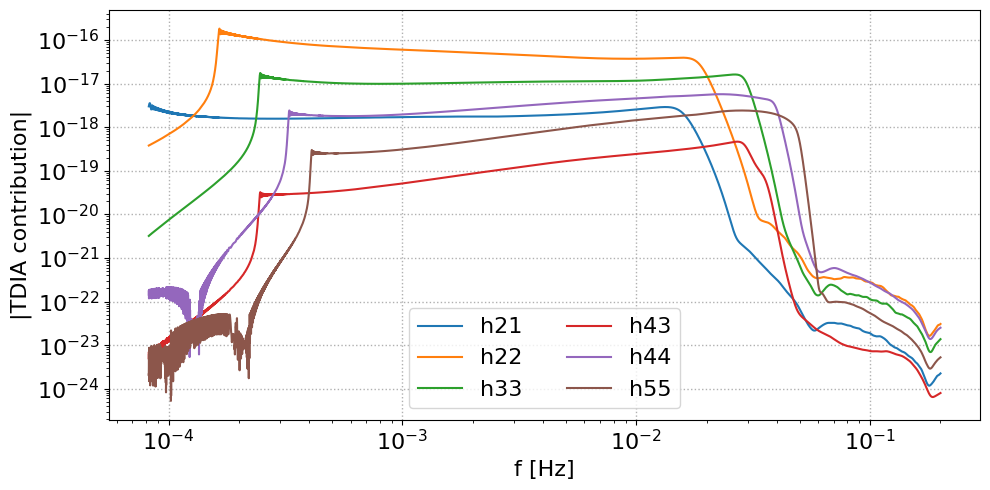

In [43]:
datalm_file = os.path.join(
    Syst_dir,
    "M1e6",
    "datalm_pseob_M1e6_id_0.h5"
)

with h5py.File(datalm_file, "r") as hf:
    print("Groups:", list(hf.keys()))

    plt.figure(figsize=(10, 5))

    for group in hf.keys():
        f = hf[group]["freq"][:]
        A = hf[group]["TDIA"][:]
        plt.loglog(f, np.abs(A), label=group)

    plt.xlabel("f [Hz]")
    plt.ylabel("|TDIA contribution|")
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

In [44]:
wftdi.keys()


dict_keys(['modes', (2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)])

In [45]:
'''# Generate and plot one pSEOB waveform directly
params_plot = copy.deepcopy(params_base)
params_plot['M'] = 1e6
params_plot_ssb, wftdi_pseob = build_wftdi_from_hlm_fd(params_plot, waveform_params_base, modes=modes, t0=waveform_params_base['t0'])

fig, ax = plt.subplots(1, 1, figsize=[10, 7])

for lm in modes:
    ax.loglog(wftdi[lm]['freq'], wftdi[lm]['amp'], linewidth=1.5, label=f'pSEOB {lm}')

ax.axvline(waveform_params_base['maxf'], color='black', linestyle='-', linewidth=1, label='max f')
ax.set_xlabel('f (Hz)', fontsize=12)
ax.set_ylabel('mode amplitude', fontsize=12)
ax.set_title(f'pSEOB generated modes - M = {params_plot["M"]:.0e}', fontsize=14)
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=10, ncol=2)
plt.tight_layout()
plt.show()'''


'# Generate and plot one pSEOB waveform directly\nparams_plot = copy.deepcopy(params_base)\nparams_plot[\'M\'] = 1e6\nparams_plot_ssb, wftdi_pseob = build_wftdi_from_hlm_fd(params_plot, waveform_params_base, modes=modes, t0=waveform_params_base[\'t0\'])\n\nfig, ax = plt.subplots(1, 1, figsize=[10, 7])\n\nfor lm in modes:\n    ax.loglog(wftdi[lm][\'freq\'], wftdi[lm][\'amp\'], linewidth=1.5, label=f\'pSEOB {lm}\')\n\nax.axvline(waveform_params_base[\'maxf\'], color=\'black\', linestyle=\'-\', linewidth=1, label=\'max f\')\nax.set_xlabel(\'f (Hz)\', fontsize=12)\nax.set_ylabel(\'mode amplitude\', fontsize=12)\nax.set_title(f\'pSEOB generated modes - M = {params_plot["M"]:.0e}\', fontsize=14)\nax.grid(True, which=\'both\', alpha=0.3)\nax.legend(fontsize=10, ncol=2)\nplt.tight_layout()\nplt.show()'

pySEOBNR TD: M=1.000e+06, q=4.000, chi1=0.500, chi2=0.500, f22_start=1.620e-04 Hz, f_from_T=1.620e-04 Hz, f_RD_est=1.624e-02 Hz, f_max=2.000e-01 Hz, deltaT=1.250e+00 s, phi_ref=0


pSEOB FD construction:
  modes kept = [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]
  freq range = 1e-05 0.2
  n_freq     = 10000


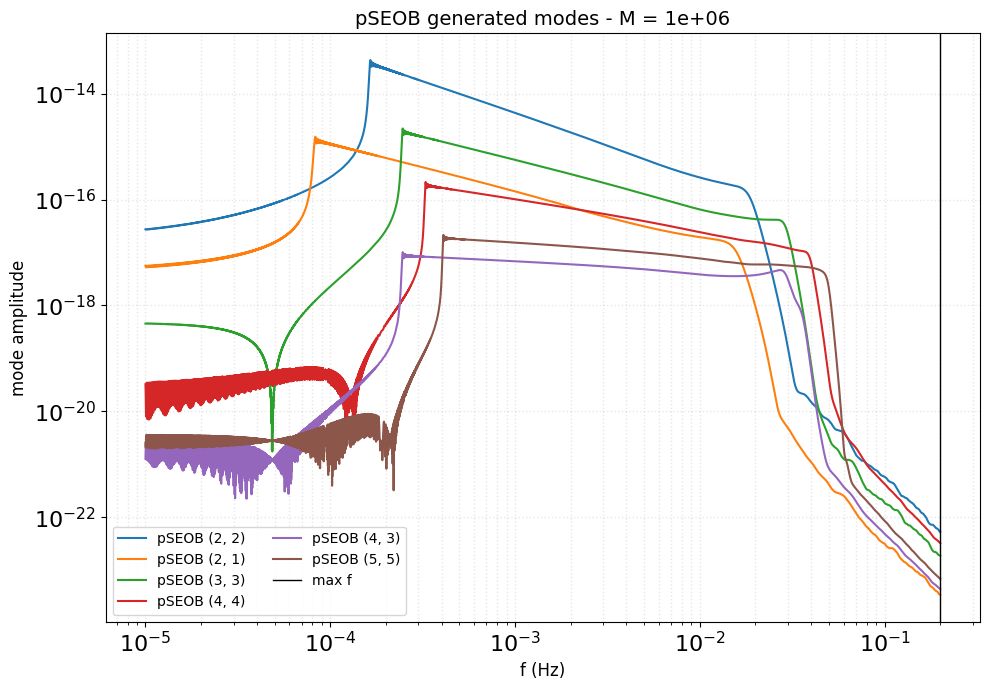

In [46]:
# Generate and plot one pSEOB waveform directly
params_plot = copy.deepcopy(params_base)
params_plot["M"] = 1e6

hlm_fd_plot = generate_pseob_fft(
    params_plot,
    modes=modes,
    waveform_params=waveform_params_base,
    verbose=True,
)

params_plot_ssb, wftdi_pseob = build_wftdi_from_hlm_fd(
    params_plot,
    hlm_fd_plot,
    modes=modes,
    t0=waveform_params_base["t0"],
)

fig, ax = plt.subplots(1, 1, figsize=[10, 7])

for lm in modes:
    if lm in wftdi_pseob:
        ax.loglog(
            wftdi_pseob[lm]["freq"],
            wftdi_pseob[lm]["amp"],
            linewidth=1.5,
            label=f"pSEOB {lm}"
        )

ax.axvline(waveform_params_base["maxf"], color="black", linestyle="-", linewidth=1, label="max f")
ax.set_xlabel("f (Hz)", fontsize=12)
ax.set_ylabel("mode amplitude", fontsize=12)
ax.set_title(f'pSEOB generated modes - M = {params_plot["M"]:.0e}', fontsize=14)
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=10, ncol=2)
plt.tight_layout()
plt.show()

Reading: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/M1e6/datalm_pseob_M1e6_id_0.h5


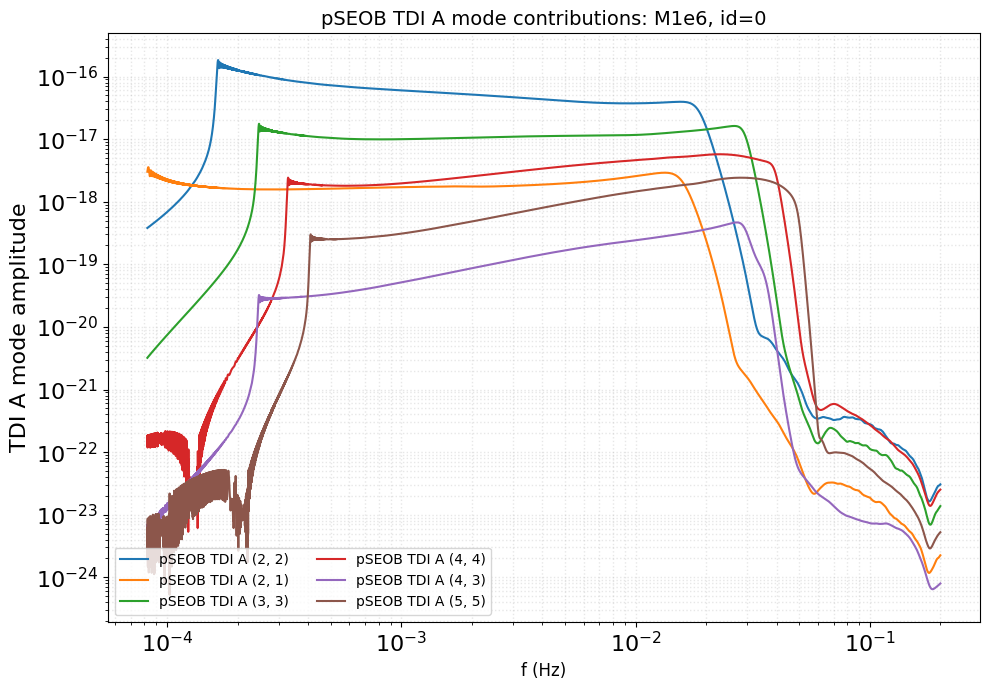

In [47]:
# one generated pSEOB datalm file
iM = 1
im = 0
m_str = listM_str[iM]
datalm_path = os.path.join(Syst_dir, m_str, f'datalm_pseob_{m_str}_id_{im}.h5')

print('Reading:', datalm_path)

fig, ax = plt.subplots(1, 1, figsize=[10, 7])

with h5py.File(datalm_path, 'r') as hf:
    for lm in modes:
        group_name = f'h{lm[0]}{lm[1]}'
        if group_name in hf:
            f = hf[group_name]['freq'][:]
            amp_A = np.abs(hf[group_name]['TDIA'][:])
            ax.loglog(f, amp_A, linewidth=1.5, label=f'pSEOB TDI A {lm}')

ax.set_xlabel('f (Hz)', fontsize=12)
ax.set_ylabel('TDI A mode amplitude')
ax.set_title(f'pSEOB TDI A mode contributions: {m_str}, id={im}', fontsize=14)
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=10, ncol=2, loc='lower left')
plt.tight_layout()
plt.show()


Reading: /pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/M1e6/data_pseob_M1e6_id_0.h5
--- pSEOB generated TDI file ---
Keys: ['TDIA', 'TDIE', 'TDIT', 'freq']
Frequency grid size: 32723
Frequency range: 8.230e-05 to 2.000e-01 Hz


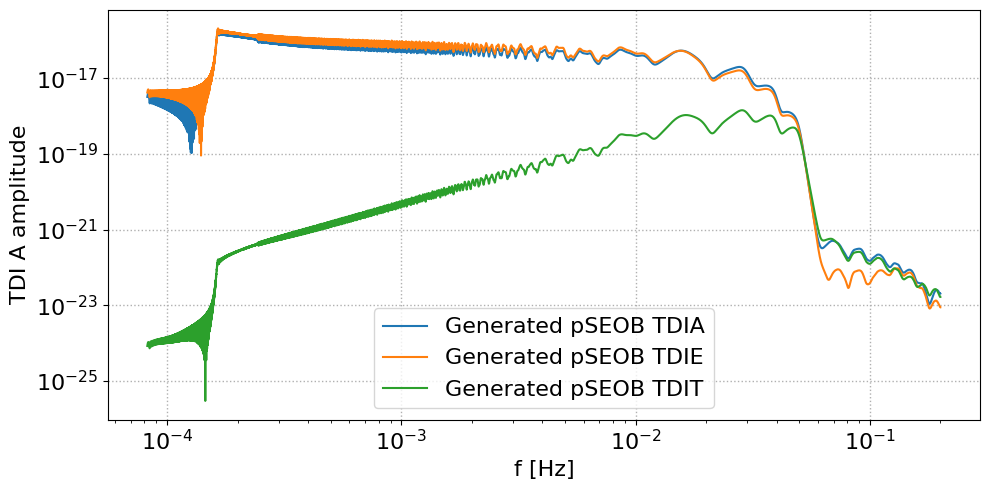

In [48]:
# Quick consistency inspection for one generated pSEOB injection file.
m_str = 'M1e6'
im = 0
file_generated = os.path.join(Syst_dir, m_str, f'data_pseob_{m_str}_id_{im}.h5')

print('Reading:', file_generated)

def inspect_file(path):
    with h5py.File(path, 'r') as hf:
        data = {k: hf[k][:] for k in hf.keys()}
    return data

gen = inspect_file(file_generated)

print(f"--- pSEOB generated TDI file ---")
print(f"Keys: {list(gen.keys())}")
print(f"Frequency grid size: {len(gen['freq'])}")
print(f"Frequency range: {gen['freq'][0]:.3e} to {gen['freq'][-1]:.3e} Hz")

plt.figure(figsize=(10, 5))
for chan in ['TDIA', 'TDIE', 'TDIT']:
    if chan in gen:
        plt.loglog(gen['freq'], np.abs(gen[chan]), label=f'Generated pSEOB {chan}')
plt.xlabel('f [Hz]')
plt.ylabel('TDI A amplitude')
plt.legend()
plt.tight_layout()
plt.show()


Groups: ['h21', 'h22', 'h33', 'h43', 'h44', 'h55']


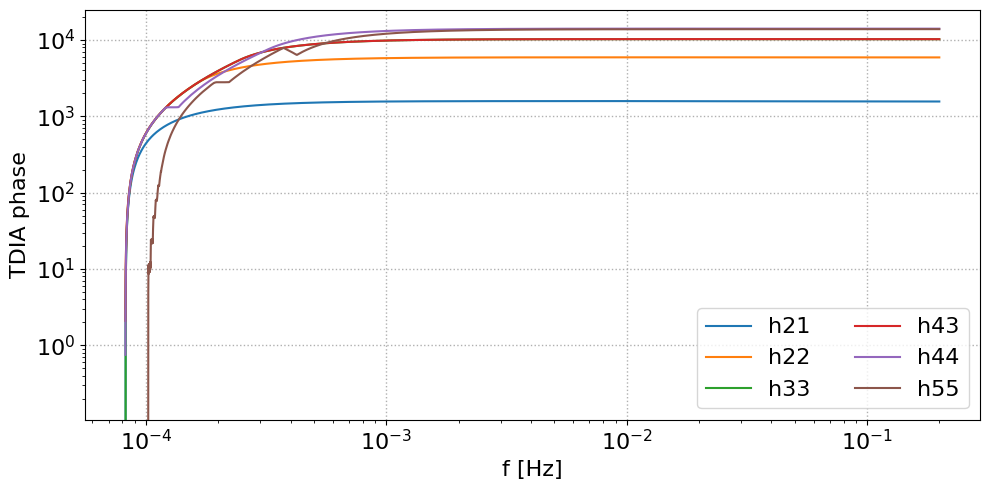

In [49]:
with h5py.File(datalm_file, "r") as hf:
    print("Groups:", list(hf.keys()))

    plt.figure(figsize=(10, 5))

    for group in hf.keys():
        f = hf[group]["freq"][:]
        A = hf[group]["TDIA"][:]
        plt.loglog(f, -np.unwrap(np.angle(A)), label=group)

    plt.xlabel("f [Hz]")
    plt.ylabel("TDIA phase")
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

In [50]:
## Daignosing the low frequency misbehave

Final TDI f_min: 8.229645274606691e-05
pSEOB f22_start: 0.00016201251676075174


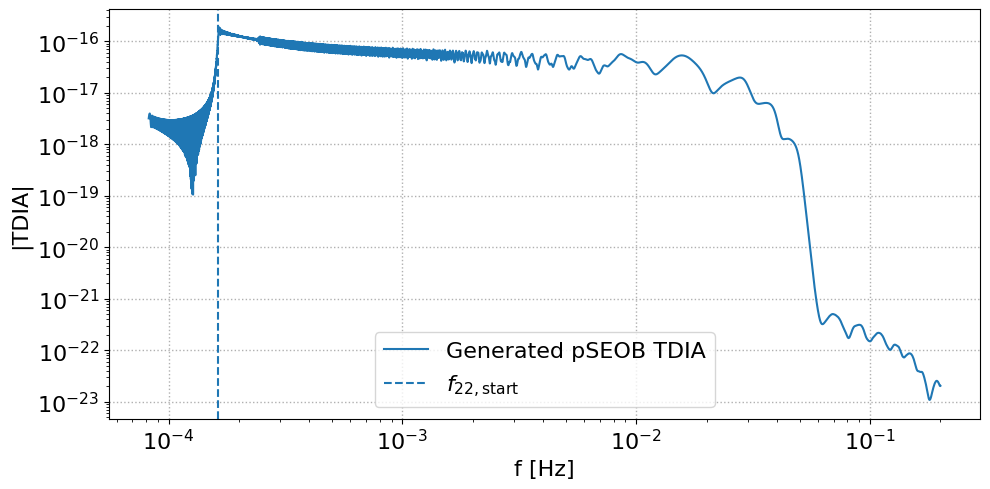

In [51]:
M = params_plot["M"]
q = params_plot["q"]
m1 = M * q / (1.0 + q)
m2 = M / (1.0 + q)

f22_start, T_obs, f_from_T = choose_f_start_from_Tobs(m1, m2, waveform_params_base)

print("Final TDI f_min:", gen["freq"][0])
print("pSEOB f22_start:", f22_start)

plt.figure(figsize=(10, 5))
plt.loglog(gen["freq"], np.abs(gen["TDIA"]), label="Generated pSEOB TDIA")
plt.axvline(f22_start, linestyle="--", label=r"$f_{22,\rm start}$")
plt.xlabel("f [Hz]")
plt.ylabel("|TDIA|")
plt.legend()
plt.tight_layout()
plt.show()